<a href="https://colab.research.google.com/github/rxphaelbihag/DS171-Intro-to-Supervised-Machine-Learning/blob/main/Regularized%20Least%20Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Laboratory Exercise 2: Regularized Least Squares

Name: Raphael Khandie B. Bihag

Student No.: 2024-05203

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

1. Preprocessing & Feature Standardization  

* Load insurance.csv and extract target variable charges (y) and independent features (Xraw: age, bmi, children, smoker).

* Compute z-score normalization for all independent variables to guarantee mean $u$ =0 and variance $z$=1.

* Split your dataset into an 80% Training Set and a 20% Test Set before applying normalization or hyperparameter selection.

* Append a vector of ones as the first column of the feature matrix X to represent the intercept w0


In [17]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 1.1 Load & Encode Dataset

# load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "abdullahcetin/mirichoi0218insurance",
  "insurance.csv",
)

# Convert binary categorical variable 'smoker' (yes=1, no=0)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Extract raw features and target variable
X_raw = df[['age', 'bmi', 'children', 'smoker']].values
y = df['charges'].values

# 1.2 Train/Test Split (Prevent Data Leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# 1.3 Feature Standardization (Z-Score Scaling)
# Fit ONLY on training data, then transform both train and test sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

Using Colab cache for faster access to the 'mirichoi0218insurance' dataset.


2. Regularized Least Squares Implementation

* Train Ridge ($L_2$) and Lasso ($L_1$) models across the specified penalty hyperparameter grid: $\lambda \in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]$.

* Implement Lasso Regression minimizing the L1-penalized cost function: J(w) = SSE + p=1Pwj. Evaluate Lasso across the same hyperparameter grid  to identify which feature weights collapse to exactly zero.

* Implement 5-fold cross-validation to determine the optimal penalty parameter * that yields the lowest mean validation error (MSE) for both Ridge and Lasso models.


In [18]:
# Grid of penalty hyperparameter values
lambdas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# results dictionaries
ridge_results = {
    "lambda" : lambdas,
    "MSE" : [],
    "R^2" : []
}

lasso_results = {
    "lambda" : lambdas,
    "MSE" : [],
    "R^2" : []
}

In [19]:
# 2.1 Ridge Regression Across Hyperparameter Grid

for l in lambdas:
    ridge_model = Ridge(alpha=l)
    ridge_model.fit(X_train, y_train)

    ridge_pred = ridge_model.predict(X_test)

    ridge_results['MSE'].append(mean_squared_error(y_test, ridge_pred))
    ridge_results['R^2'].append(r2_score(y_test, ridge_pred))

In [20]:
# 2.2 Lasso Regression Across Hyperparameter Grid

for l in lambdas:
    lasso_model = Lasso(alpha=l)
    lasso_model.fit(X_train, y_train)

    lasso_pred = lasso_model.predict(X_test)

    lasso_results['MSE'].append(mean_squared_error(y_test, lasso_pred))
    lasso_results['R^2'].append(r2_score(y_test, lasso_pred))

In [21]:
# 2.3 Optimal Hyperparameter Selection via 5-Fold Cross-Validation

# define the k-fold object
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# define the Ridge regression with the k-fold object
ridgecv = RidgeCV(alphas=lambdas, cv=kf)
ridgecv.fit(X_train, y_train)

# define the Ridge regression with the k-fold object
lassocv = LassoCV(alphas=lambdas, cv=kf)
lassocv.fit(X_train, y_train)

kfold_results = {
    "Model": ['Ridge', 'Lasso'],
    "Best Lambda": [ridgecv.alpha_, lassocv.alpha_]
}

In [22]:
# transform to df all results
ridge_results_df = pd.DataFrame(ridge_results)
lasso_results_df = pd.DataFrame(lasso_results)
kfold_results_df = pd.DataFrame(kfold_results)

In [23]:
ridge_results_df

,lambda,MSE,R^2
0,0.001,3.398166e+07,0.781115
1,0.010,3.398171e+07,0.781114
2,0.100,3.398223e+07,0.781111
3,1.000,3.398748e+07,0.781077
4,10.000,3.404865e+07,0.780683
5,100.000,3.537780e+07,0.772122
6,1000.000,6.432434e+07,0.585669
7,10000.000,1.338598e+08,0.137772


In [24]:
lasso_results_df

,lambda,MSE,R^2
0,0.001,3.398165e+07,0.781115
1,0.010,3.398166e+07,0.781115
2,0.100,3.398175e+07,0.781114
3,1.000,3.398262e+07,0.781109
4,10.000,3.399164e+07,0.781050
5,100.000,3.411679e+07,0.780244
6,1000.000,3.811600e+07,0.754484
7,10000.000,1.553914e+08,-0.000919


In [25]:
kfold_results_df

,Model,Best Lambda
0,Ridge,1.000
1,Lasso,0.001


3. Plots and output evaluation
* Plot feature weight coefficients (w1,w2,w3,w4) as a function of 10() for both Ridge and Lasso to visually contrast uniform coefficient shrinkage versus sparse feature selection.

* Generate a plot displaying Training MSE vs. Validation MSE across 10() values to illustrate the optimal regularization.

* Compute and output evaluation metrics comparing unregularized OLS (from Lab 1) against optimal Ridge and optimal Lasso models:


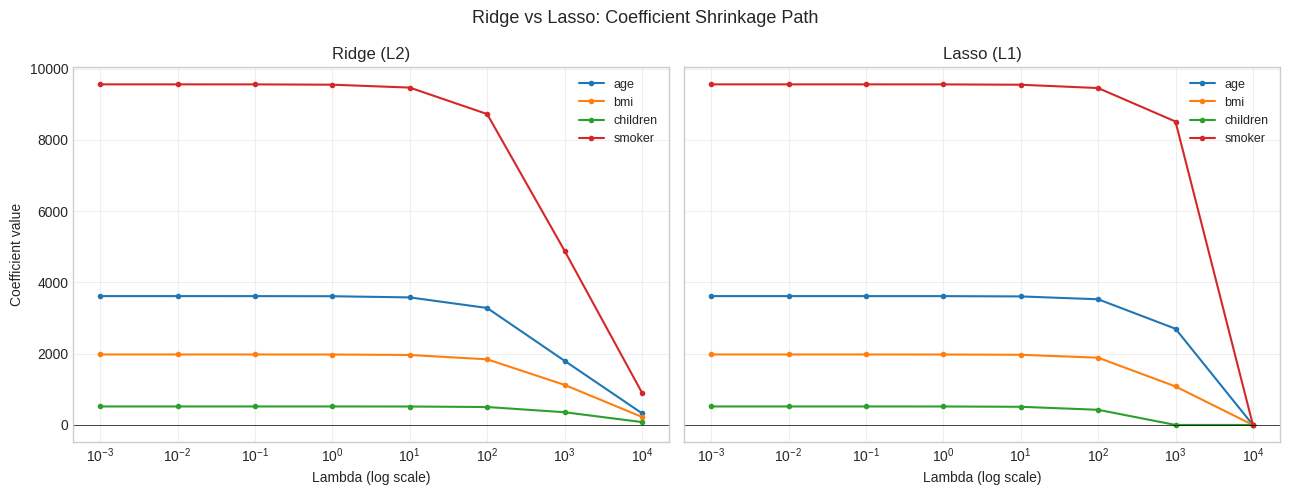

In [26]:
# 3.1 Coefficient Shrinkage Path Visualization

# specify feature names and colors for graph readability
feature_names = ['age', 'bmi', 'children', 'smoker']
colors = ['C0', 'C1', 'C2', 'C3']

# matrices to store the coefficients
ridge_coefs = np.zeros((len(lambdas), 4))
lasso_coefs = np.zeros((len(lambdas), 4))

# calculate Ridge and Lasso coefficients across all lambdas
for i, l in enumerate(lambdas):
    ridge_coefs[i] = Ridge(alpha=l).fit(X_train, y_train).coef_
    lasso_coefs[i] = Lasso(alpha=l, max_iter=50000).fit(X_train, y_train).coef_

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for j in range(4):
    axes[0].plot(lambdas, ridge_coefs[:, j], marker='o', ms=3,
                 color=colors[j], label=feature_names[j])
    axes[1].plot(lambdas, lasso_coefs[:, j], marker='o', ms=3,
                 color=colors[j], label=feature_names[j])

for ax, title in zip(axes, ['Ridge (L2)',
                            'Lasso (L1)']):
    ax.set_xscale('log')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Lambda (log scale)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

axes[0].set_ylabel('Coefficient value')
plt.suptitle('Ridge vs Lasso: Coefficient Shrinkage Path', fontsize=13)
plt.tight_layout()
plt.show()

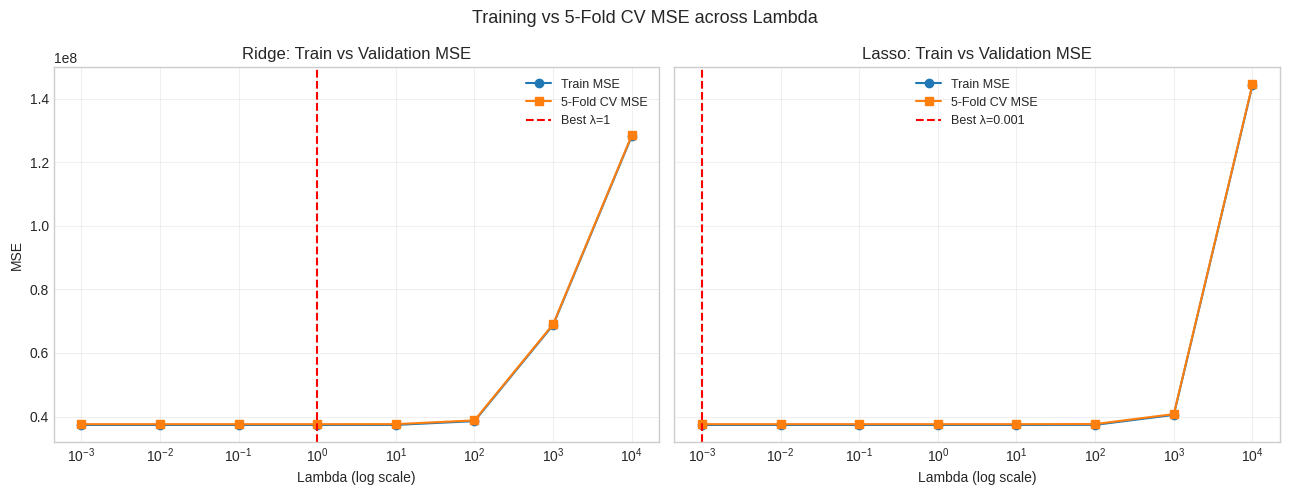

Ridge best λ (from CV curves) = 1
Lasso best λ (from CV curves) = 0.001


In [27]:
# 3.2 Train MSE vs Validation MSE Curve for Ridge

# K-fold object initialization
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# lists to store the results
ridge_train_mse, ridge_val_mse = [], []
lasso_train_mse, lasso_val_mse = [], []

# for loop to iterate over all the lambdas
for l in lambdas:

    # manual loop since RidgeCV and LassoCV does not store per-fold results
    r_tr, r_va, l_tr, l_va = [], [], [], []
    for tr_idx, va_idx in kf.split(X_train):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        # Ridge
        r = Ridge(alpha=l).fit(X_tr, y_tr)
        r_tr.append(mean_squared_error(y_tr, r.predict(X_tr)))
        r_va.append(mean_squared_error(y_va, r.predict(X_va)))

        # Lasso
        ls = Lasso(alpha=l, max_iter=50000).fit(X_tr, y_tr)
        l_tr.append(mean_squared_error(y_tr, ls.predict(X_tr)))
        l_va.append(mean_squared_error(y_va, ls.predict(X_va)))

    ridge_train_mse.append(np.mean(r_tr)); ridge_val_mse.append(np.mean(r_va))
    lasso_train_mse.append(np.mean(l_tr)); lasso_val_mse.append(np.mean(l_va))

# get the best lambdas from CV
ridge_best_lambda = lambdas[int(np.argmin(ridge_val_mse))]
lasso_best_lambda = lambdas[int(np.argmin(lasso_val_mse))]

# plotting
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].plot(lambdas, ridge_train_mse, marker='o', label='Train MSE')
axes[0].plot(lambdas, ridge_val_mse,   marker='s', label='5-Fold CV MSE')
axes[0].axvline(ridge_best_lambda, color='red', ls='--',
                label=f'Best λ={ridge_best_lambda:.3g}')
axes[0].set_title('Ridge: Train vs Validation MSE')

axes[1].plot(lambdas, lasso_train_mse, marker='o', label='Train MSE')
axes[1].plot(lambdas, lasso_val_mse,   marker='s', label='5-Fold CV MSE')
axes[1].axvline(lasso_best_lambda, color='red', ls='--',
                label=f'Best λ={lasso_best_lambda:.3g}')
axes[1].set_title('Lasso: Train vs Validation MSE')

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('Lambda (log scale)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('MSE')
plt.suptitle('Training vs 5-Fold CV MSE across Lambda', fontsize=13)
plt.tight_layout()
plt.savefig('train_val_mse.png', dpi=120)
plt.show()

print(f"Ridge best λ (from CV curves) = {ridge_best_lambda}")
print(f"Lasso best λ (from CV curves) = {lasso_best_lambda}")

In [28]:
# 3.3 Final Model Evaluation Matrix (in table format)

# Unregularized OLS as baseline
ols = LinearRegression().fit(X_train, y_train)

# Refit best Ridge & Lasso on full training set
best_ridge = Ridge(alpha=ridgecv.alpha_).fit(X_train, y_train)
best_lasso = Lasso(alpha=lassocv.alpha_, max_iter=50000).fit(X_train, y_train)

# function for easy evaluation
def evaluate(name, model):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    coef = model.coef_
    return {
        'Model':            name,
        'Train MSE':        mean_squared_error(y_train, y_pred_train),
        'Test MSE':         mean_squared_error(y_test,  y_pred_test),
        'Test RMSE':        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Test R²':          r2_score(y_test, y_pred_test),
        'Non-zero coefs':   int(np.sum(np.abs(coef) > 1e-8)),
        '||w||₂':           float(np.linalg.norm(coef)),
    }

rows = [
    evaluate('OLS (unregularized)', ols),
    evaluate(f'Ridge (λ={ridgecv.alpha_:.3g})', best_ridge),
    evaluate(f'Lasso (λ={lassocv.alpha_:.3g})', best_lasso),
]
comparison_df = pd.DataFrame(rows).set_index('Model')
coef_df = pd.DataFrame({
    'OLS':   ols.coef_,
    'Ridge': best_ridge.coef_,
    'Lasso': best_lasso.coef_,
}, index=feature_names)

In [29]:
print("Evaluation Metrics Comparison")
comparison_df

Evaluation Metrics Comparison


,Train MSE,Test MSE,Test RMSE,Test R²,Non-zero coefs,||w||₂
Model,,,,,,
OLS (unregularized),3.736960e+07,3.398165e+07,5829.378522,0.781115,4,10423.154930
Ridge (λ=1),3.736969e+07,3.398748e+07,5829.877977,0.781077,4,10413.236105
Lasso (λ=0.001),3.736960e+07,3.398165e+07,5829.378604,0.781115,4,10423.153451


In [30]:
print("Coefficient Comparision")
coef_df

Coefficient Comparision


,OLS,Ridge,Lasso
age,3616.318176,3612.646905,3616.317283
bmi,1978.420432,1976.974833,1978.419530
children,519.225287,519.084437,519.224352
smoker,9559.323158,9550.203682,9559.322121


4. Analytical Questions
Answer the following questions in a dedicated Markdown cell at the end of your notebook (3–5 sentences per answer).

* Why must feature standardization ($Z$-score scaling) be applied prior to fitting regularized regression models, and what happens to coefficient penalties if features remain unscaled?

* How do $L_1$ and $L_2$ penalties differ in their mathematical geometry, and why does Lasso force feature coefficients to become exactly zero while Ridge only shrinks them asymptotically?

* How does adding the regularization term $\lambda I$ to the design matrix cross-product ($X^T X$) solve the linear algebra problem of matrix singularity/non-invertibility in multicollinear datasets?

Answers
> Regularized regression penalizes the magnitude of coefficients such that a feature measured on a large scale needs only a small coefficient to influence the prediction, while a small-scale feature needs a large one. Without standardization, the penalty therefore falls disproportionately on small-scale features, shrinking them more aggressively purely because of their units rather than their predictive importance. Z-score scaling puts all features on a comparable scale (mean 0, std 1) so the penalty treats each coefficient fairly and the chosen λ reflects true model complexity rather than unit artifacts. If features remain unscaled, the regularization becomes arbitrary and the resulting model is biased toward features with large numeric ranges.

> The $L_2$ penalty constrains coefficients to lie within a smooth hypersphere ($ \lVert w \rVert_{2}^{2} \leq t$), whereas the $L_{1}$ penalty constrains them to lie within a diamond-shaped polytope ($\lVert w \rVert_{1} \leq t$) with sharp corners sitting exactly on the coordinate axes. Because the OLS loss contours are ellipses centered on the unregularized solution, the regularized solution is where those contours first touch the constraint region. The diamond's corners lie on the axes, so the ellipse frequently touches at a corner where one or more coefficients are exactly zero, producing sparsity. The circle has no such corners such that its smooth surface is tangent to the ellipse at a point with generally nonzero coordinates; so, Ridge only shrinks coefficients smoothly toward (but never reaching) zero, except in the limit $\lambda \rightarrow \infty$.

> OLS requires inverting $X^T X$, but when features are perfectly or highly collinear, $X^T X$ becomes singular or ill-conditioned, so no unique solution exists or the solution has explosive variance. Ridge regression solves $(X^{T}X + \lambda I) w = X^{T}y$ instead, adding $\lambda$ to every diagonal entry of the Gram matrix. Since $\lambda > 0$, all eigenvalues of $X^{T}X$ are shifted up by $\lambda$, so even zero eigenvalues become positive and the matrix becomes strictly positive definite; hence, always invertible and well-conditioned. This guarantees a unique, stable solution whose coefficients are shrunk toward zero, trading a small amount of bias for a large reduction in variance, which is exactly why Ridge handles multicollinearity gracefully.



##Submission:
Save all your code and analysis answers in a single Jupyter notebook. Make sure that your notebook has the student number, full name, and section commented in the first cell. Export the notebook with complete executed outputs and save it following the filename format “surname_section_labexe2.ipynb”.
- Submit your notebook to the LMS submission bin on or before the specified deadline.
- Late submission will be subject to a point deduction (10% per day, up to a 3-day maximum delay).
- Submissions that do not comply with the stated requirements and guidelines will be graded 0. Refer to the course syllabus for details on the source code evaluation rubric.
